Paso 1: Limpieza fina de tu columna
Aarón ha rellenado los huecos vacíos de ai_skills con la etiqueta "Not Specified".

Lo primero que he hecho en mi script de Python es filtrar el dataframe para excluir esos "Not Specified".

In [1]:
import pandas as pd

# 1. Cargamos y limpiamos 
df = pd.read_csv('ai_impact_jobs_2010_2025_GOLD.csv')
df_skills = df[df['ai_skills'] != 'Not Specified'].copy()

# 2. Rompemos las comas, separamos las palabras y contamos
habilidades_separadas = df_skills['ai_skills'].str.split(', ').explode()
top_skills = habilidades_separadas.value_counts().head(10)

# 3. Imprimimos el resultado
print(" EL RANKING OFICIAL DE SKILLS DE IA ")
print(top_skills)

 EL RANKING OFICIAL DE SKILLS DE IA 
ai_skills
reinforcement learning    325
NLP                       323
MLOps                     318
deep learning             307
computer vision           302
machine learning          287
generative AI             188
LLMs                      164
Name: count, dtype: int64


Paso 3: La Evolución Temporal (2010 vs 2025)
Para que tu análisis sea de matrícula, no saques solo un Top 10 general.

Filtra los datos por año (posting_year) y compara el Top 5 de habilidades que se pedían en 2010 con el Top 5 que se pide en 2025. Así demostrarás cómo ha evolucionado el mercado.


In [2]:
df_2010 = df_skills[df_skills['posting_year'] == 2010]
df_2025 = df_skills[df_skills['posting_year'] == 2025]

top_2010 = df_2010['ai_skills'].str.split(', ').explode().value_counts().head(5)

top_2025 = df_2025['ai_skills'].str.split(', ').explode().value_counts().head(5)

print(" TOP 5 HABILIDADES EN 2010:")
print("-" * 30)
print(top_2010)

print("\n TOP 5 HABILIDADES EN 2025:")
print("-" * 30)
print(top_2025)

 TOP 5 HABILIDADES EN 2010:
------------------------------
ai_skills
reinforcement learning    8
computer vision           7
NLP                       7
MLOps                     6
deep learning             6
Name: count, dtype: int64

 TOP 5 HABILIDADES EN 2025:
------------------------------
ai_skills
NLP                       40
computer vision           33
reinforcement learning    33
deep learning             32
LLMs                      32
Name: count, dtype: int64


Paso 4: El Análisis de "Reskilling"
Usando la columna booleana reskilling_required (True/False), calcula qué porcentaje exacto de los trabajos actuales te obligan a reciclarte profesionalmente.

In [3]:
porcentajes = df['reskilling_required'].value_counts(normalize=True) * 100

print(" PORCENTAJE DE OFERTAS QUE EXIGEN RECICLAJE (RESKILLING):")
print("-" * 55)
print(porcentajes.round(1)) 

 PORCENTAJE DE OFERTAS QUE EXIGEN RECICLAJE (RESKILLING):
-------------------------------------------------------
reskilling_required
False    68.7
True     31.3
Name: proportion, dtype: float64


Paso 5: Visualización
Tendrás que generar los gráficos para el informe. Para el ranking de habilidades, lo mejor es un Gráfico de Barras Horizontales (queda muy limpio para leer textos) o una Nube de Palabras (Wordcloud).

Para el porcentaje de reskilling, un Gráfico de Quesito (Pie Chart) o un gráfico de anillo (Donut Chart) es perfecto.

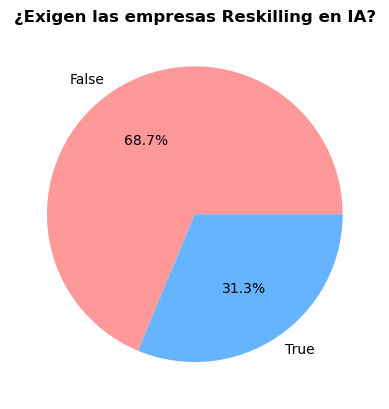

In [4]:
import matplotlib.pyplot as plt
reskilling = df['reskilling_required'].value_counts()

reskilling.plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999', '#66b3ff'])
plt.title('¿Exigen las empresas Reskilling en IA?', fontweight='bold')
plt.ylabel('') # Esto quita un texto feo que sale a la izquierda por defecto
plt.show()

<Axes: ylabel='ai_skills'>

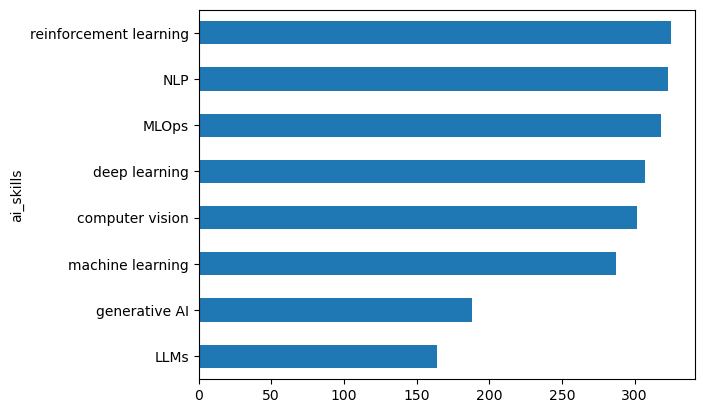

In [6]:

top_skills.sort_values().plot(kind='barh')

<Axes: xlabel='posting_year'>

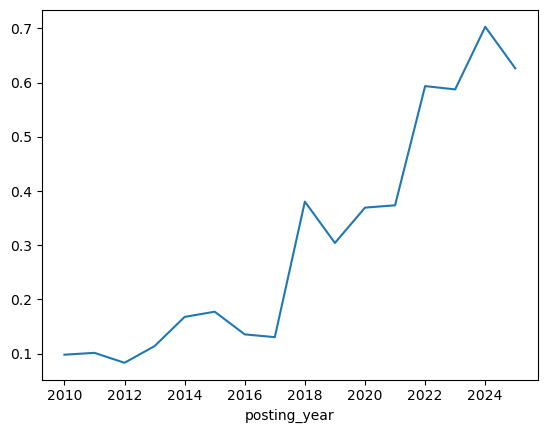

In [7]:
df.groupby('posting_year')['reskilling_required'].mean().plot(kind='line')